In [58]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch.nn as nn
from torch.utils.data import Dataset, random_split, DataLoader, TensorDataset
import math


# Q1 Simulation Set up

In [59]:
def simulate_sir_simple(lam, mu, I_0, T=100, N=1000):
    '''
    arg:
    N total population
    --- parameters not directely known ---
    lam infection rate
    mu recovery rate
    I_0 initial number of infected
    --------------------------------------
    T number of days

    returns:
    x sequence of observations [(Delta S(1), Delta R(1)), ... ]
    c sequence of ODE variables [(S(1), I(1), R(1)), .... ]
    '''
    # initial conditions
    S = N - I_0
    I = I_0
    R = 0

    S_list = [S]
    I_list = [I]
    R_list = [R]

    # simulate day-by-day
    for t in range(T):
        # dynamics
        dS = -lam * S * I / N
        dI = lam * S * I / N - mu * I
        dR = mu * I

        # update
        S += dS
        I += dI
        R += dR

        # store
        S_list.append(S)
        I_list.append(I)
        R_list.append(R)

    # Convert to numpy for easier ops
    S_arr = np.array(S_list)
    I_arr = np.array(I_list)
    R_arr = np.array(R_list)

    # Observations: ΔS(t), ΔR(t), t=1..T
    dS = S_arr[:-1] - S_arr[1:]
    dR = R_arr[1:] - R_arr[:-1]

    x = np.stack([dS, dR], axis=1)
    c = np.stack([S_arr[1:], I_arr[1:], R_arr[1:]], axis=1)
    return x, c


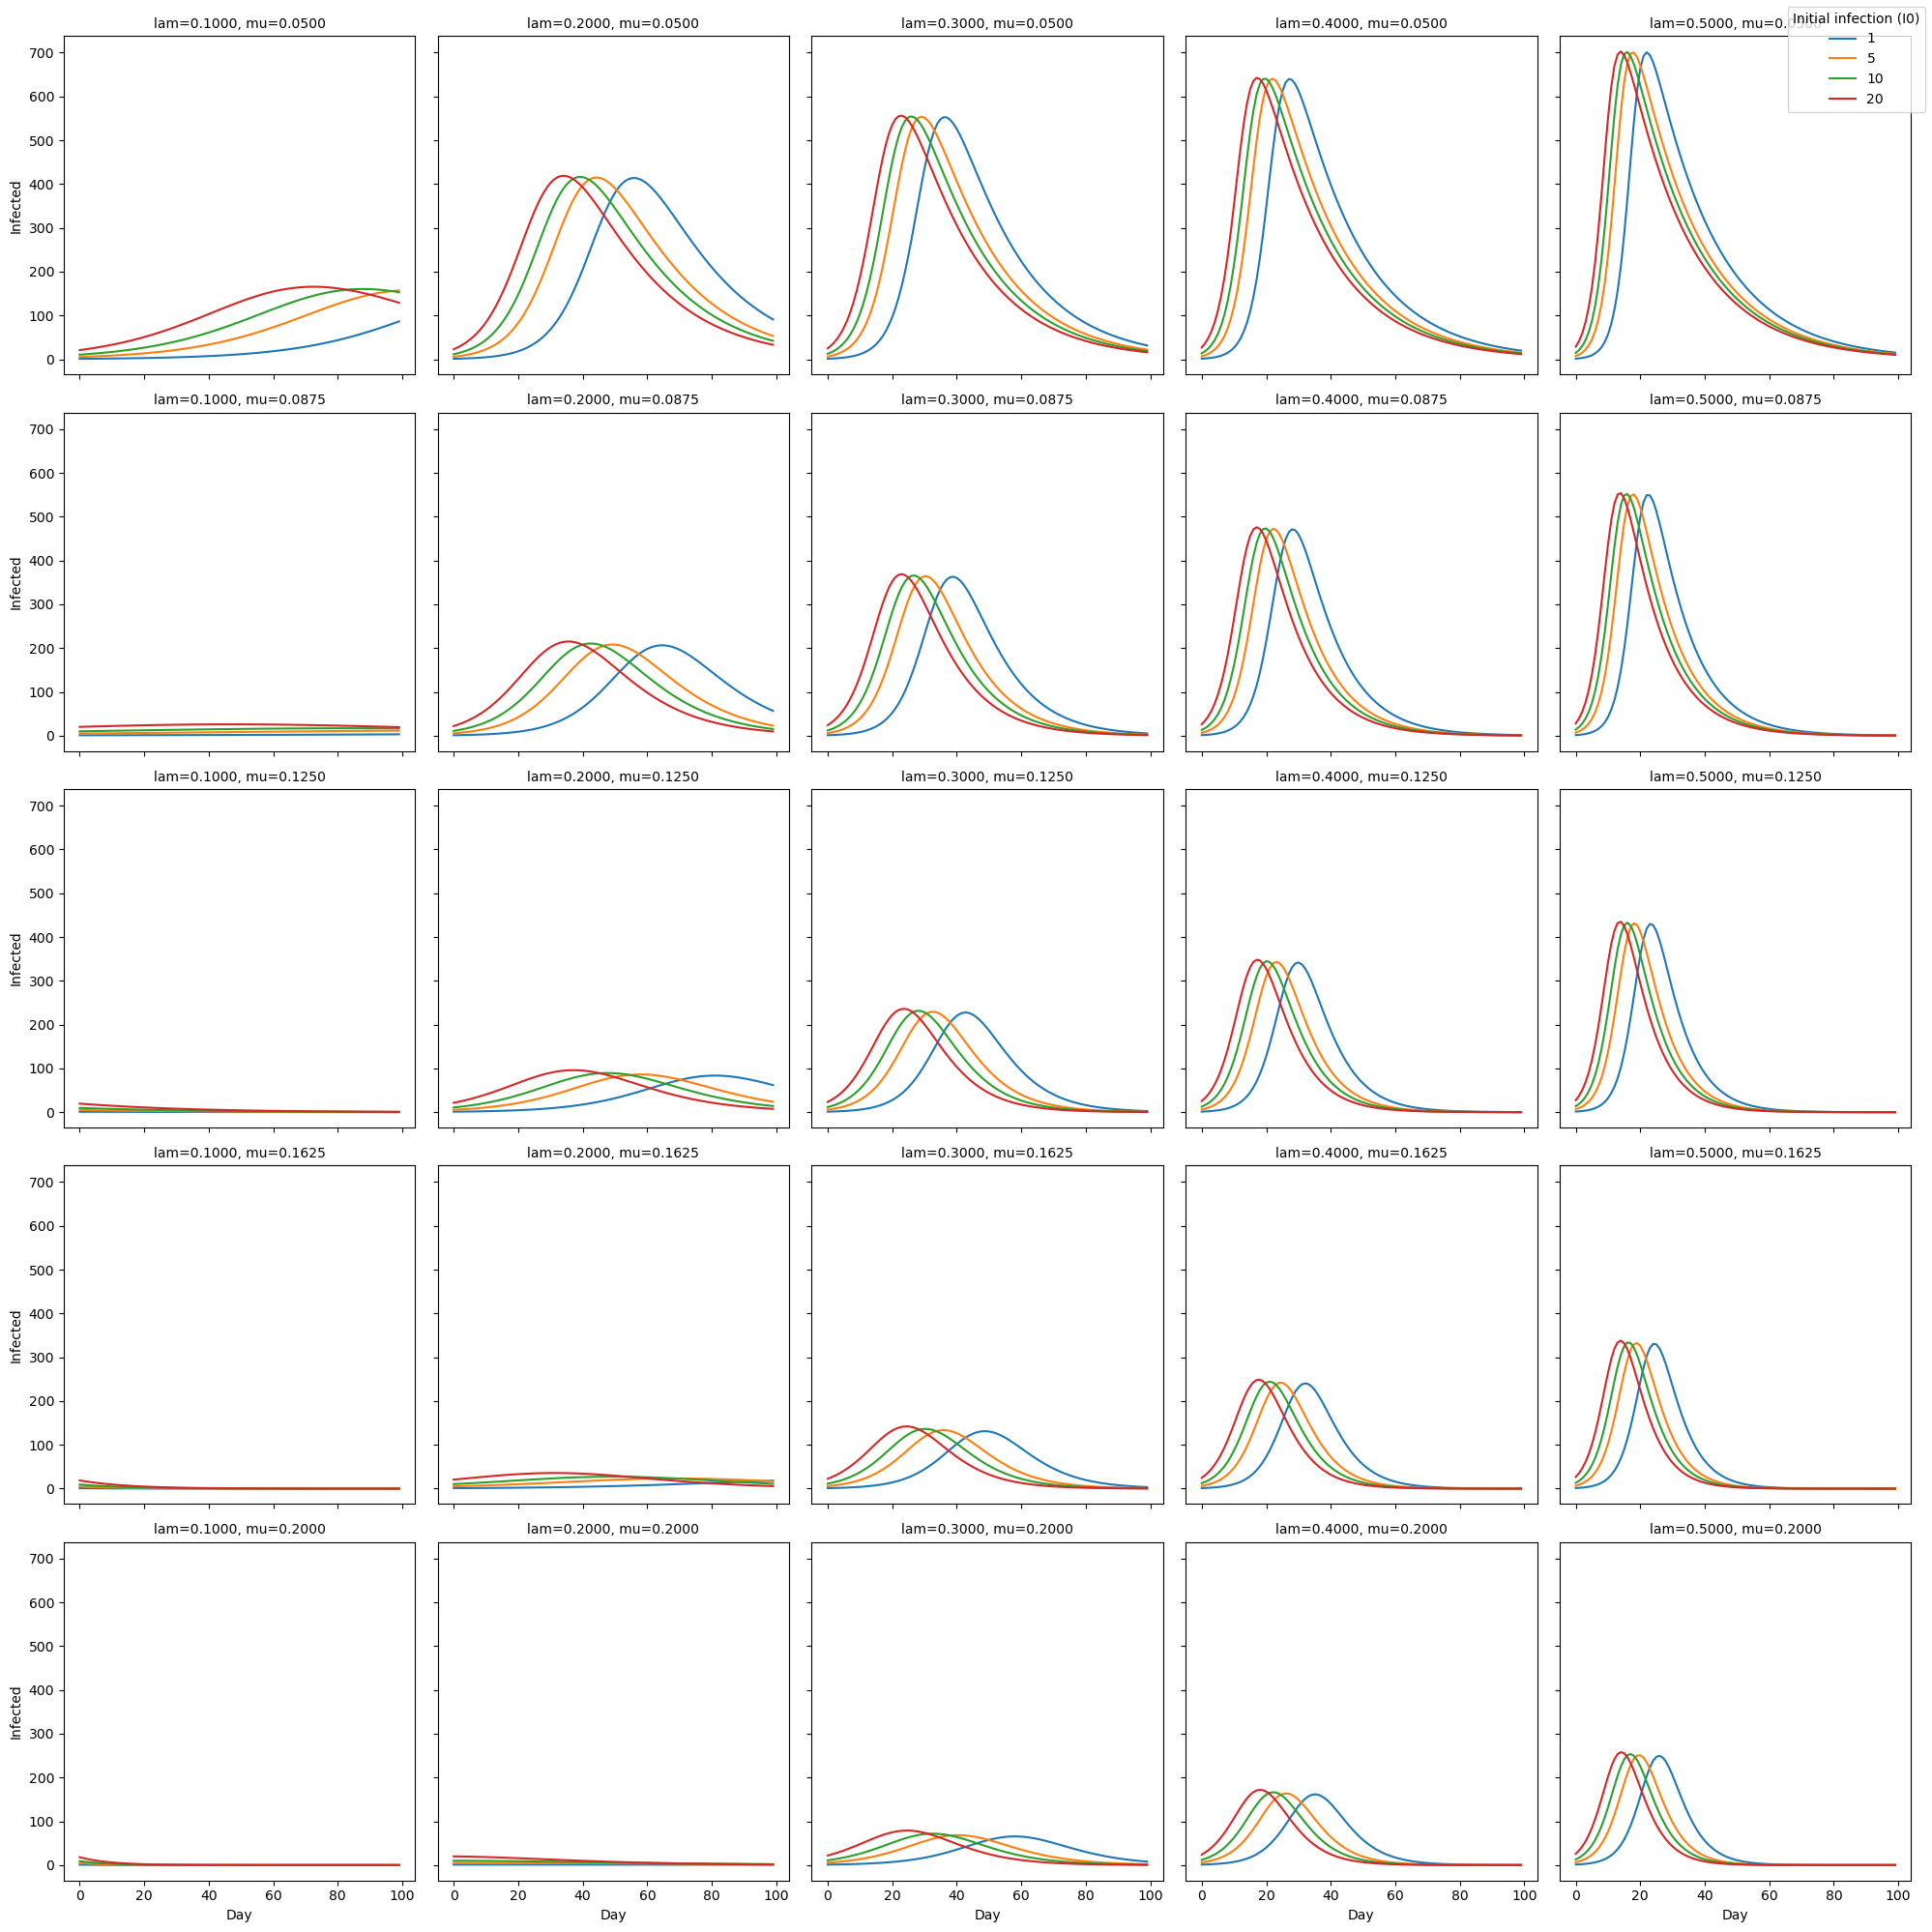

In [60]:
lams = np.linspace(0.1, 0.5, 5)
mus = np.linspace(0.05, 0.2, 5)
I0s = [1, 5, 10, 20]

T = 100

fig, axes = plt.subplots(len(mus), len(lams), figsize=(20, 20), sharex=True, sharey=True)

for i, mu in enumerate(mus):
    for j, lam in enumerate(lams):
        ax = axes[i, j]
        
        for I0 in I0s:
            x, c = simulate_sir_simple(lam, mu, I0, T)
            I = c[:, 1]  # infected curve
            ax.plot(I, label=f"I0={I0}")

        ax.set_title(f"lam={lam:.4f}, mu={mu:.4f}", fontsize=10)
        
        if i == len(mus)-1:
            ax.set_xlabel("Day")
        if j == 0:
            ax.set_ylabel("Infected")

# Only one legend outside the whole grid
fig.legend(I0s, title="Initial infection (I0)", loc="upper right")
plt.tight_layout()
plt.show()


I'll choose \lambda = 0.3 - 0.5, \mu = 0.05 - 0.1625, I_0 = 5-20

# Q2 Point Estimation

In [73]:
# generate sample from the chosen SIR model
def sample_prior(n):
    '''
    Draw the prior Y for p^sim(Y) = p^sim(lam) p^sim(mu) p^sim(I_0) from uniform distributions
    n draws
    '''
    lam = np.random.uniform(0.4, 0.5, size=n)
    mu  = np.random.uniform(0.05, 0.1625, size=n)
    I0  = np.random.uniform(5, 20, size=n)
    return np.stack([lam, mu, I0], axis=1)


class SIRDataset(Dataset):

    def __init__(self, n, T=100, N=10000):
        '''
        n: number of samples
        T: days
        N: population
        '''
        self.T = T
        self.N = N

        y = sample_prior(n) # draw n sets of priors (lam, mu, I0) (n,3)
        X = []
        Y = []

        for lam, mu, I0 in y:
            x, _ = simulate_sir_simple(lam, mu, I0, T=T, N=N) # x: (T,2)
            x = x / N
            X.append(x.reshape(-1))
            Y.append([lam, mu, np.log(I0)])

        self.X = torch.tensor(np.array(X), dtype=torch.float32)
        self.Y = torch.tensor(np.array(Y), dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]
    
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [74]:
## Regression network
class MLPRegressor(nn.Module):
    """
    y = Phi(x)
    """
    def __init__(self, in_dim=200, hidden=(256, 256), out_dim=3):
        super().__init__()
        layers = []
        d = in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU()]
            d = h
        layers += [nn.Linear(d, out_dim)] # last layer
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)
    
## Model trainer
def train(model, train_loader, val_loader, epochs=30, lr=1e-3, device="cpu"):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for ep in range(1, epochs+1):
        model.train()
        tr_loss = 0.0
        for X, Y in train_loader:
            X, Y = X.to(device), Y.to(device)
            pred = model(X)
            loss = loss_fn(pred, Y)
            opt.zero_grad()
            loss.backward()
            opt.step()
            tr_loss += loss.item() * X.size(0)
        tr_loss /= len(train_loader.dataset)

        model.eval()
        va_loss = 0.0
        with torch.no_grad():
            for X, Y in val_loader:
                X, Y = X.to(device), Y.to(device)
                pred = model(X)
                loss = loss_fn(pred, Y)
                va_loss += loss.item() * X.size(0)
        va_loss /= len(val_loader.dataset)

        # print(f"epoch {ep:3d} | train MSE {tr_loss:.5f} | val MSE {va_loss:.5f}")

# model evaluation
def evaluate(model, loader, device="cpu"):
    model.eval()
    Ys, Ps = [], []
    with torch.no_grad():
        for X, Y in loader:
            X = X.to(device)
            pred = model(X).cpu()
            Ys.append(Y)
            Ps.append(pred)
    Y = torch.cat(Ys, 0).numpy()
    P = torch.cat(Ps, 0).numpy()

    # undo log(I0)
    Y[:, 2] = np.exp(Y[:, 2])
    P[:, 2] = np.exp(P[:, 2])

    mse = ((P - Y)**2).mean(axis=0)
    print("MSE (lam, mu, I0):", mse)

    names = ["lam", "mu", "I0"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for k in range(3):
        ax = axes[k]
        ax.scatter(Y[:, k], P[:, k], s=5, alpha=0.3)
        mn = min(Y[:, k].min(), P[:, k].min())
        mx = max(Y[:, k].max(), P[:, k].max())
        ax.plot([mn, mx], [mn, mx], color='b')
        ax.set_title(f"{names[k]}: pred vs true")
        ax.set_xlabel("true")
        ax.set_ylabel("pred")
    plt.tight_layout()
    plt.show()


MSE (lam, mu, I0): [2.7593267e-05 1.7539238e-05 6.9582120e-02]


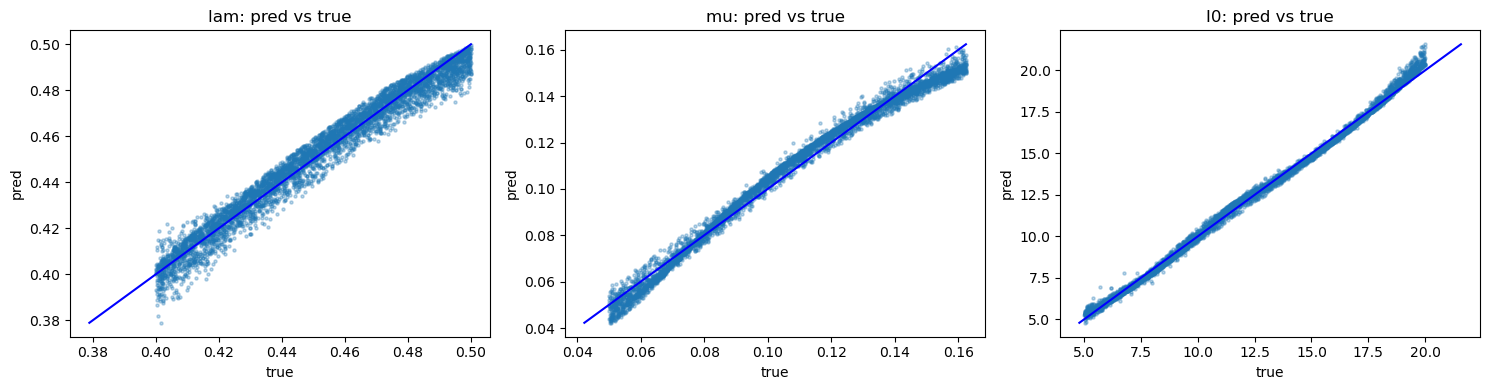

In [75]:
n = 50000
ds = SIRDataset(n=n) 
n_train = int(0.8 * n) 
n_val   = int(0.1 * n)
n_test  = n - n_train - n_val
train_ds, val_ds, test_ds = random_split(ds, [n_train, n_val, n_test])

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=512, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=512, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = MLPRegressor(in_dim=2*T, hidden=(256,256))
train(model, train_loader, val_loader, epochs=30, lr=1e-3, device=device)

evaluate(model, test_loader, device=device)



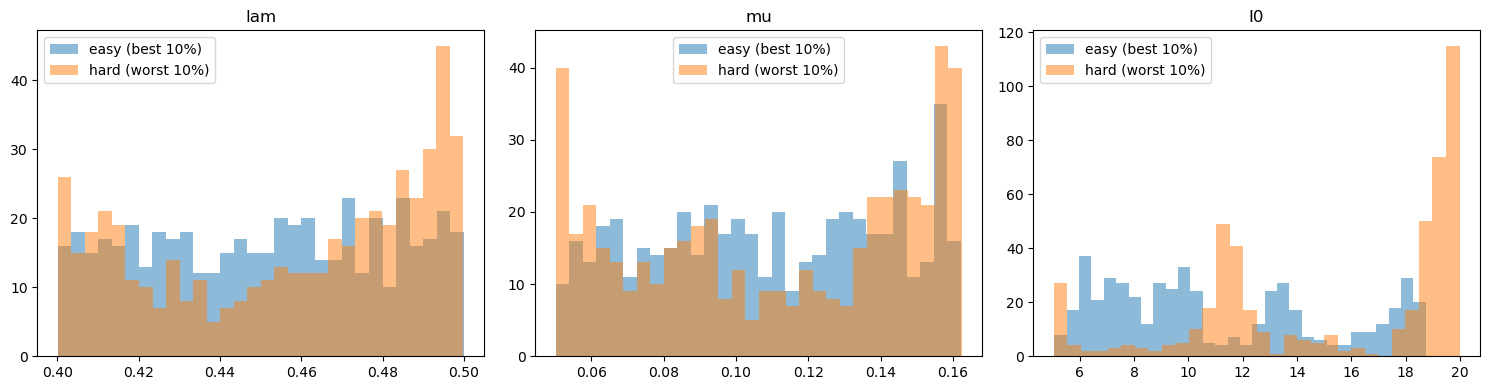

In [76]:
def difficulty_analysis(model, loader, device="cpu"):
    model.eval()
    Ys, Ps = [], []
    with torch.no_grad():
        for X, Y in loader:
            X = X.to(device)
            pred = model(X).cpu()
            Ys.append(Y)
            Ps.append(pred)
    Y = torch.cat(Ys, 0).numpy()
    P = torch.cat(Ps, 0).numpy()

    Y[:, 2] = np.exp(Y[:, 2])
    P[:, 2] = np.exp(P[:, 2])

    err = np.sqrt(((P - Y)**2).sum(axis=1))  # overall error per sample
    thr = np.quantile(err, 0.9)              # worst 10%
    hard = Y[err >= thr]
    easy = Y[err <= np.quantile(err, 0.1)]

    names = ["lam", "mu", "I0"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for k in range(3):
        axes[k].hist(easy[:, k], bins=30, alpha=0.5, label="easy (best 10%)")
        axes[k].hist(hard[:, k], bins=30, alpha=0.5, label="hard (worst 10%)")
        axes[k].set_title(names[k])
        axes[k].legend()
    plt.tight_layout()
    plt.show()

difficulty_analysis(model, test_loader, device=device)


# Q3. Posterior Estimation

### Model Implementation

In [77]:
# Summary Network
class SummaryNet(nn.Module):
    def __init__(self, phi: nn.Module, out_dim = 64):
        '''Remove the last layer of the input network phi and use it as summary network'''
        super().__init__()
        self.backbone = nn.Sequential(*list(phi.net.children())[:-1]) # remove last layer of phi(x)
        last_linear = None
        for m in reversed(list(self.backbone.children())):
            if isinstance(m, nn.Linear):
                last_linear = m
                break
        if last_linear is None:
            raise RuntimeError("No Linear layer found in backbone")
        
        self.proj = nn.Linear(last_linear.out_features, out_dim)

    def forward(self, x):
        z = self.backbone(x)
        z = self.proj(z)
        return z
    
##  conditional coupling flow from task 3 HW 3
def subnet_constructor(input_size, hidden_size, output_size):
    model = nn.Sequential(
        nn.Linear(input_size, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size,hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, output_size)
    )
    return model

def orthogonal_matrix(dim):
    A = torch.normal(mean=torch.zeros(dim,dim), std=torch.ones(dim, dim))
    Q, _ = torch.linalg.qr(A)
    return Q


# conditional coupling block
class conditional_coupling_block(nn.Module):
    def __init__(self, input_size, hidden_size, condition_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.condition_size = condition_size

        self.split1 = self.input_size // 2
        self.split2 = self.input_size - self.split1

        self.subnet = subnet_constructor(self.split1+ self.condition_size, 
                                         self.hidden_size, 
                                         2 * self.split2) # output: s, t
    
    def forward(self, x, cond, rev=False):
        x1, x2 = x[..., :self.split1], x[..., self.split1: ]

        params = self.subnet(torch.cat([x1, cond], -1)) # get s, t from subnetwork
        s, t = params[..., :self.split2], params[..., self.split2: ]
        s = torch.tanh(s)
        ljd = torch.sum(s, -1)
        
        if not rev:
            x2 = torch.exp(s) * x2 + t # affine transformation on split 2
            return torch.cat([x1,x2], -1), ljd
        
        else:
            x2 = torch.exp(-s) * (x2 - t)
            return torch.cat([x1, x2], -1)

class conditional_realNVP(nn.Module):
    def __init__(self, input_size, hidden_size, n_blocks, condition_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.n_blocks = n_blocks
        self.condition_size = condition_size

        self.coupling_blocks = nn.ModuleList([
            conditional_coupling_block(input_size, hidden_size, condition_size) for _ in range(n_blocks)
        ])

        self.register_buffer(
            "orthogonal_matrices",
            torch.stack([orthogonal_matrix(input_size) for _ in range(n_blocks-1)], dim=0)
        )

    def forward(self, x, cond, rev=False):
        if rev:
            return self._inverse(x, cond)
        return self._forward(x, cond)
        
    def _forward(self, x, cond):
        ljd = torch.zeros((x.shape[0]))
        for l in range(self.n_blocks-1):
            x, partial_ljd = self.coupling_blocks[l](x, cond)
            ljd += partial_ljd
            x = torch.matmul(x, self.orthogonal_matrices[l])
        x, partial_ljd = self.coupling_blocks[-1](x, cond)
        ljd += partial_ljd
        return x, ljd
    
    def _inverse(self, x, cond):
       
        for l in range(self.n_blocks-1, 0, -1):
            x = self.coupling_blocks[l](x, cond, rev=True)
            x = torch.matmul(x, self.orthogonal_matrices[l-1].T)
        x = self.coupling_blocks[0](x, cond, rev=True)
        return x
    
    def log_prob(self, y, cond):
        z, ljd = self.forward(y, cond, rev=False)
        log_base = -0.5 * (z**2).sum(dim=-1) - 0.5 * self.input_size * math.log(2*math.pi)
        return log_base + ljd
    
    def sample(self, num_samples, cond):
        if cond.dim() == 1:
            cond = cond.unsqueeze(0) # (1, cond_dim)
        B = cond.shape[0]
        z = torch.randn(B * num_samples, self.input_size) # z ~ N(0,I)
        cond_rep = cond.repeat_interleave(num_samples, dim=0) # (c[0], c[0]..., c[1],....)
        y = self._inverse(z, cond_rep) # y = f^-1(z;c)
        return y


def train_posterior(summary_net, flow, loader, device="cpu", epochs=30, lr=1e-3):
    summary_net.to(device)
    flow.to(device)

    opt = torch.optim.Adam(list(summary_net.parameters()) + list(flow.parameters()), lr=lr)

    for ep in range(1, epochs+1):
        summary_net.train()
        flow.train()
        total = 0.0 

        for X, Y in loader:
            X, Y = X.to(device), Y.to(device)
            cond = summary_net(X) # h(x) = z
            logp = flow.log_prob(Y, cond) # log p(y|h(x))
            loss = (-logp).mean() # NLL

            opt.zero_grad()
            loss.backward()
            opt.step()

            total += loss.item() * X.size(0)
        print(f"epoch {ep:3d} | NLL {total / len(loader.dataset):.4f}")

### Visualization

In [102]:
def plot_1d_marginals(flow, 
                      summary_net, 
                      phi, # MLPRegressor
                      x, 
                      y_true, 
                      device='cpu', n_samples=5000, 
                      lam_range=(0.4, 0.5), mu_range=(0.05, 0.1625), I0_range=(5,20)
                      ):
    '''
    Plot 1D marginal posteriors p(lam|x), p(mu|x), p(I0|x)
    for a given observation(prior) x
    with prior, ground truth and point estimate.
    '''
    flow.eval()
    summary_net.eval()
    phi.eval()

    ## flow condition
    x = x.to(device).unsqueeze(0)

    with torch.no_grad():
        cond = summary_net(x) # (1, cond_dim)
        y_samples = flow.sample(n_samples, cond) # marginal posterior p() (n_samples, 3)
        y_samples = y_samples.cpu().numpy()
        y_point = phi(x).cpu().numpy()[0] # point estimate using MLPRegressor (3,) 
    
    y_true = np.asarray(y_true)

    ## priors
    priors = [
        np.random.uniform(*lam_range, size=10000), # p^sim(lam)
        np.random.uniform(*mu_range, size=10000), # p^sim(mu)
        np.random.uniform(*I0_range, size=10000), # p^sim(I0)
        # np.random.uniform(*np.log(mu_range), size=10000)
    ]
    names  = [r"$\lambda$", r"$\mu$", r"$I_0$"]
    ranges = [lam_range, mu_range, I0_range]

    ## plots
    fig, axes = plt.subplots(1,3, figsize=(15,4))

    for k, ax in enumerate(axes): # iterate over [lam, mu, I0]
        if k == 2: # undo log(I_0)
            samples = np.exp(y_samples[:, k])
            truth   = np.exp(y_true[k])
            point   = np.exp(y_point[k])
        else:
            samples = y_samples[:, k]
            truth   = y_true[k]
            point   = y_point[k]
        
        # samples = y_samples[:, k]
        # truth   = y_true[k]
        # point   = y_point[k]

        # posterior
        ax.hist(
            samples,
            bins=60,
            density=True,
            alpha=0.6,
            label='posterior (samples)',
        )

        # prior
        # a, b = ranges[k]
        # ax.hlines(
        #     1.0 / (b - a),
        #     a,
        #     b,
        #     linestyles="--",
        #     linewidth=2,
        #     label="prior (uniform)",
        # )
        ax.hist(
            priors[k],
            bins=60,
            density=True,
            alpha=0.6,
            label='prior',
        )

        # ground truth & point estimate
        ax.axvline(truth, color="red", linewidth=2, label="true")
        ax.axvline(point, color="black", linestyle=":", linewidth=2, label="point est")

        ax.set_xlabel(names[k])
        ax.set_title(names[k])

    axes[0].legend()
    plt.tight_layout()
    plt.show()

    print("y_true (lam, mu, logI0):", y_true)
    print("y_point(lam, mu, logI0):", y_point)


    

MSE (lam, mu, I0): [6.7362754e-04 1.4457032e-04 5.2882111e-01]


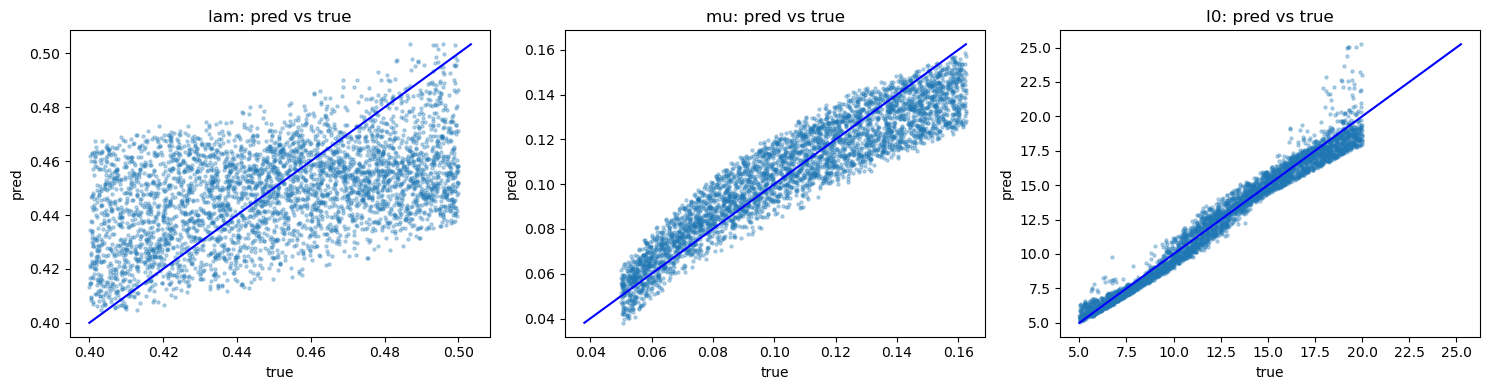

epoch   1 | NLL -0.7201
epoch   2 | NLL -3.5123
epoch   3 | NLL -4.0016
epoch   4 | NLL -4.5022
epoch   5 | NLL -5.1840
epoch   6 | NLL -5.4461
epoch   7 | NLL -5.8868
epoch   8 | NLL -6.2885
epoch   9 | NLL -6.4083
epoch  10 | NLL -6.4682
epoch  11 | NLL -5.8804
epoch  12 | NLL -6.5849
epoch  13 | NLL -7.0799
epoch  14 | NLL -6.9560
epoch  15 | NLL -7.2773
epoch  16 | NLL -5.6940
epoch  17 | NLL -7.2383
epoch  18 | NLL -7.3894
epoch  19 | NLL -7.5897
epoch  20 | NLL -7.6026
epoch  21 | NLL -7.8223
epoch  22 | NLL -7.3956
epoch  23 | NLL -7.9317
epoch  24 | NLL -7.9216
epoch  25 | NLL -7.7799
epoch  26 | NLL -8.0535
epoch  27 | NLL -8.0129
epoch  28 | NLL -2.4871
epoch  29 | NLL -7.6318
epoch  30 | NLL -7.9542


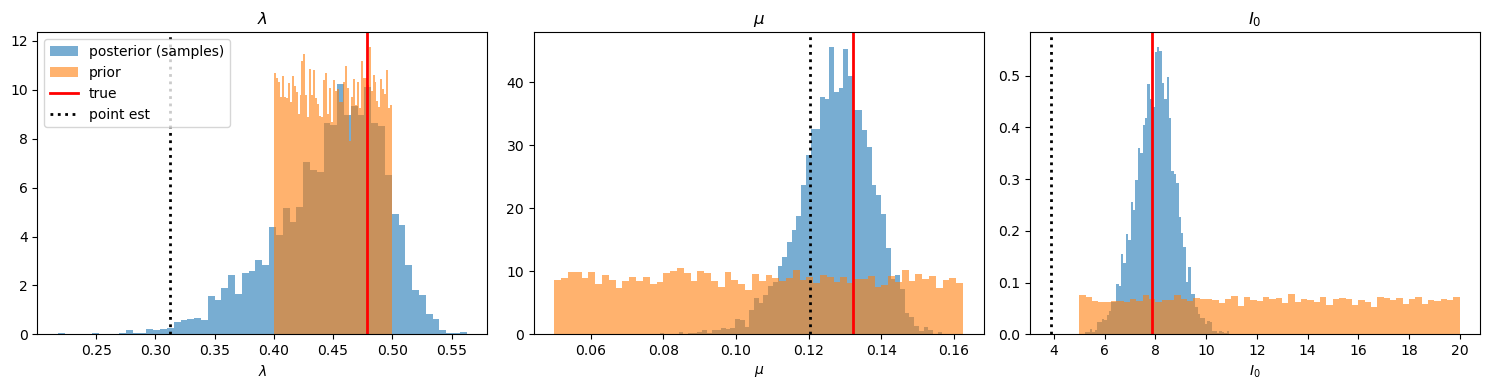

y_true (lam, mu, logI0): [0.47824386 0.13227603 2.0623777 ]
y_point(lam, mu, logI0): [0.3120495  0.12024905 1.3538479 ]


In [103]:
# dataset
dataset = SIRDataset(n=20000, T=100, N=10000)

n_train = int(0.8 * len(dataset))
n_val   = len(dataset) - n_train
train_set, val_set = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_set, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=256, shuffle=False)


# point estimator (Phi(x))
phi = MLPRegressor(in_dim=200, hidden=(256,256), out_dim=3)

train(
    model=phi,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=1e-3,
    device=device
)

evaluate(phi, val_loader, device=device)


# summary network (h(x))
summary_net = SummaryNet(phi, out_dim=64)

# conditional flow
flow = conditional_realNVP(
    input_size=3,        # (lam, mu, I0)
    hidden_size=128,
    n_blocks=6,
    condition_size=64
)

# train the conditional flow
train_posterior(
    summary_net=summary_net,
    flow=flow,
    loader=train_loader,
    device=device,
    epochs=30,
    lr=1e-3
)

# test observation x
X_test, Y_test = next(iter(val_loader))

x = X_test[0].to(device)        # (200,)
y_true = Y_test[0].numpy()      # (3,)


# visualize
plot_1d_marginals(
    flow=flow,
    summary_net=summary_net,
    phi=phi,
    x=x,
    y_true=y_true,
    device=device,
    n_samples=5000,
    lam_range=(0.4, 0.5),
    mu_range=(0.05, 0.1625),
    I0_range=(5, 20),
)


In [116]:
def plot_2d_posteriors(
    flow,
    summary_net,
    phi,
    x,
    y_true,
    device="cpu",
    n_samples=5000,
    lam_range=(0.4, 0.5),
    mu_range=(0.05, 0.3),
    I0_range=(5, 20),
):
    """
    Plot 2D posterior distributions:
    (lam, mu), (lam, I0), (mu, I0)
    including prior, truth, and point estimate.
    """

    flow.eval()
    summary_net.eval()
    phi.eval()

    # --- get posterior samples ---
    x = x.to(device).unsqueeze(0)

    with torch.no_grad():
        cond = summary_net(x)
        y_samples = flow.sample(n_samples, cond).cpu().numpy()
        y_point = phi(x).cpu().numpy()[0]

    y_true = np.asarray(y_true)

    # undo log(I0)
    y_samples[:, 2] = np.exp(y_samples[:, 2])
    y_point[2] = np.exp(y_point[2])
    y_true[2]  = np.exp(y_true[2])

    # --- draw prior samples ---
    prior = np.stack([
        np.random.uniform(*lam_range, n_samples),
        np.random.uniform(*mu_range, n_samples),
        np.random.uniform(*I0_range, n_samples),
    ], axis=1)

    pairs = [
        (0, 1, r"$\lambda$", r"$\mu$"),
        (0, 2, r"$\lambda$", r"$I_0$"),
        (1, 2, r"$\mu$", r"$I_0$"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (i, j, xi, yj) in zip(axes, pairs):

        # posterior density
        h_post, xedges, yedges = np.histogram2d(
            y_samples[:, i],
            y_samples[:, j],
            bins=60,
            density=True,
        )
        xc = 0.5 * (xedges[:-1] + xedges[1:])
        yc = 0.5 * (yedges[:-1] + yedges[1:])
        ax.contour(
            xc,
            yc,
            h_post.T,
            levels=6,
            colors="C0",
            linewidths=1,
            label="posterior",
        )

        # prior density
        h_prior, _, _ = np.histogram2d(
            prior[:, i],
            prior[:, j],
            bins=[xedges, yedges],
            density=True,
        )
        ax.contour(
            xc,
            yc,
            h_prior.T,
            levels=6,
            colors="C1",
            linestyles="dashed",
            linewidths=1,
        )

        # truth & point estimate
        ax.scatter(
            y_point[i],
            y_point[j],
            color="black",
            s=120,
            marker="^",
            facecolors="none",
            label="point est",
        )

        ax.scatter(
            y_true[i],
            y_true[j],
            color="red",
            s=120,
            marker="x",
            label="truth",
        )

        ax.set_xlabel(xi)
        ax.set_ylabel(yj)

    axes[0].legend()
    plt.tight_layout()
    plt.show()


/var/folders/_3/mcfg84vj1rg_d1rxtct_g2y00000gn/T/ipykernel_8872/3892059347.py:64: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(


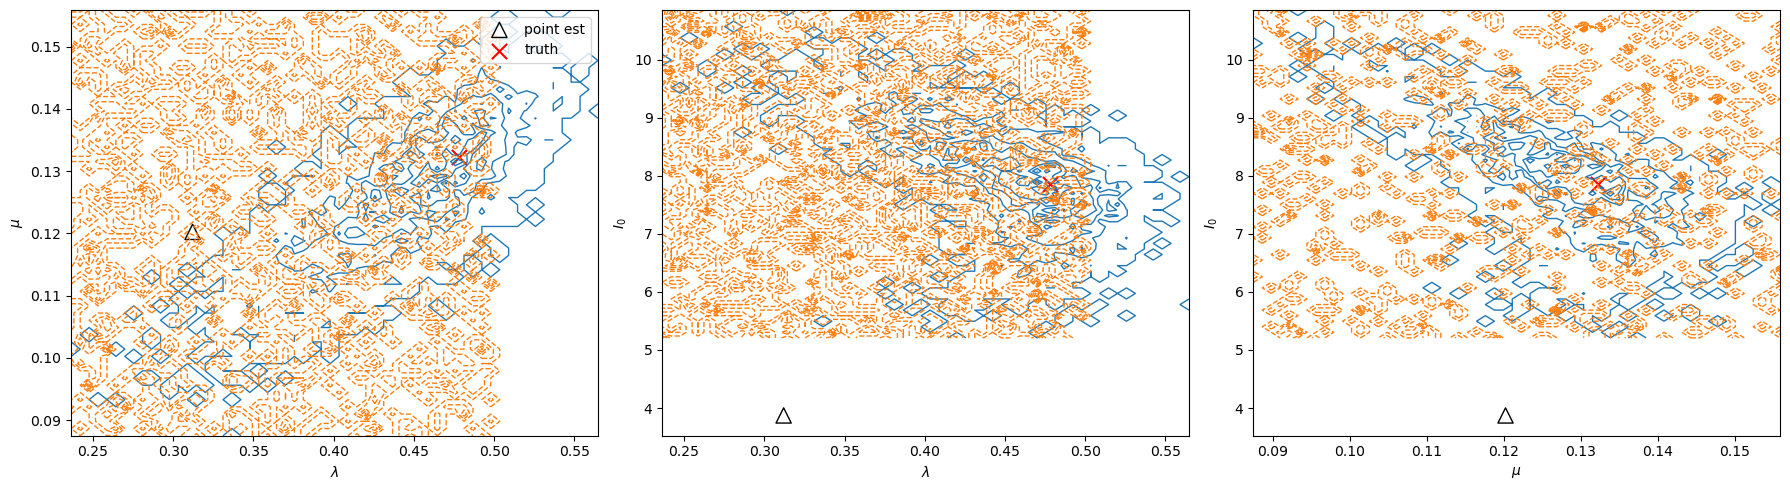

In [117]:
X_val, Y_val = next(iter(val_loader))

x_test = X_val[0].to(device)        # (200,)
y_true = Y_val[0].cpu().numpy()     # (lam, mu, log I0)

plot_2d_posteriors(
    flow=flow,
    summary_net=summary_net,
    phi=phi,
    x=x_test,
    y_true=y_true,
    device=device,
    n_samples=6000,
    lam_range=(0.1, 0.5),
    mu_range=(0.05, 0.3),
    I0_range=(5, 20),
)

2D posterior distribution reveal correlation between the inferred parameters, which is not provided by the point estimation. There is a positive correlation between $\lambda$ and $\mu$. The infection rate $\lambda$ and the initial number of infection shows some negative correlation. These correlation captures the physical structure of the inverse problem. 

In [106]:
def resimulate_from_posterior(
    flow,
    summary_net,
    x_obs,
    T=100,
    N=10000,
    n_post=200,
    device="cpu",
):
    """
    Sample parameters from posterior p(y|h(x)),
    resimulate trajectories x_hat(t).
    Returns array of shape (n_post, T).
    """

    flow.eval()
    summary_net.eval()

    x_obs = x_obs.to(device).unsqueeze(0)

    with torch.no_grad():
        cond = summary_net(x_obs)
        y_samples = flow.sample(n_post, cond).cpu().numpy()

    # undo log(I0)
    y_samples[:, 2] = np.exp(y_samples[:, 2])

    trajectories = []

    for lam, mu, I0 in y_samples:
        x_hat, _ = simulate_sir_simple(lam, mu, I0, T=T, N=N)
        delta_S = x_hat[:, 0]   # ΔS(t)
        trajectories.append(delta_S)

    return np.stack(trajectories, axis=0)  # (n_post, T)


In [ ]:
def plot_resimulation_band(
    trajectories_list,
    x_true_list,
    y_true_list=None,   # (lam, mu, logI0) 리스트
    n_cols=2,
    title="Resimulation with 50% confidence band",
):
    """
    trajectories_list: list of (n_post, T)
    x_true_list:       list of (T,)
    y_true_list:       list of (3,) -> (lam, mu, logI0), optional
    """

    n_plots = len(trajectories_list)
    n_rows = int(np.ceil(n_plots / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 3.5 * n_rows),
        sharex=True,
        sharey=True,
    )

    axes = np.atleast_1d(axes).flatten()

    for i, (traj, x_true) in enumerate(zip(trajectories_list, x_true_list)):
        ax = axes[i]

        q25 = np.percentile(traj, 25, axis=0)
        q50 = np.percentile(traj, 50, axis=0)
        q75 = np.percentile(traj, 75, axis=0)

        t = np.arange(len(x_true))

        ax.fill_between(t, q25, q75, alpha=0.4, label="50% band")
        ax.plot(t, q50, lw=2, label="posterior median")
        ax.plot(t, x_true, color="black", lw=2, label="true trajectory")

        if y_true_list is not None:
            lam, mu, logI0 = y_true_list[i]
            I0 = np.exp(logI0)
            ax.set_title(
                rf"x[{i}]  $(\lambda={lam:.3f},\ \mu={mu:.3f},\ I_0={I0:.1f})$"
            )
        else:
            ax.set_title(f"x[{i}]")

    # remove unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    axes[0].set_ylabel(r"$\Delta S(t)$")
    for ax in axes[-n_cols:]:
        ax.set_xlabel("day")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])
    plt.show()


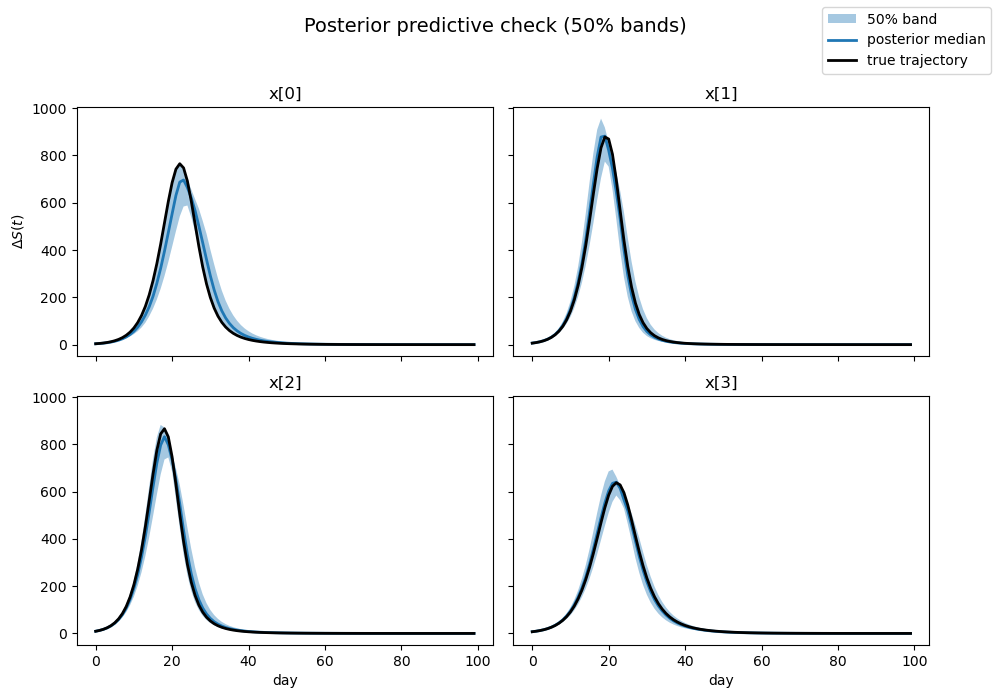

In [125]:
trajectories_list = []
x_true_list = []

X_val, Y_val = next(iter(val_loader))

for i in range(4):  
    x_test = X_val[i].to(device)
    y_true = Y_val[i].cpu().numpy()

    # true trajectory
    x_true, _ = simulate_sir_simple(
        lam=y_true[0],
        mu=y_true[1],
        I_0=np.exp(y_true[2]),
        T=100,
        N=10000,
    )
    delta_S_true = x_true[:, 0]

    # posterior resimulation
    traj = resimulate_from_posterior(
        flow=flow,
        summary_net=summary_net,
        x_obs=x_test,
        T=100,
        N=10000,
        n_post=300,
        device=device,
    )

    trajectories_list.append(traj)
    x_true_list.append(delta_S_true)

# plot all at once
plot_resimulation_band(
    trajectories_list,
    x_true_list,
    n_cols=2,
    title="Posterior predictive check (50% bands)",
)


50% posterior band onsistently cover the true trajectory for all tested x values. 